# Flux Spectrum and E-Index Analysis

This example demonstrates how to attach a neutron flux spectrum to a `Benchmark` using a Serpent detector file, visualize it with `FluxSpectrum.plot_spectrum`, and compute the E-index similarity matrix via `AssimilationSuite.e_index_matrix`. The E-index quantifies the cosine similarity between sensitivity profiles without the influence of a nuclear data covariance matrix.

### 1. Setup and Imports
We import `andalus` for the core logic and `matplotlib` for visualization.

In [1]:
import matplotlib.pyplot as plt

import andalus

### 2. Reading Serpent Output
We load the **HMF001** (Godiva) benchmark using `Benchmark.from_serpent`. The optional `flux_det` argument attaches a `FluxSpectrum` by reading a named detector from a Serpent `_det0.m` file. Here we pass the detector name `"flux"` and the path to the detector output file.

The `pertlist` filters the sensitivity output to the most physically relevant reactions:
* `mt 2 xs`: Elastic scattering
* `mt 18 xs`: Fission
* `mt 102 xs`: Radiative capture
* `nubar prompt`: Average prompt neutron multiplicity
* `chi prompt`: Prompt fission neutron spectrum

In [2]:
hmf001 = andalus.Benchmark.from_serpent(
    title="HMF001",
    m=1.0,
    dm=0.001,
    sens0_path="../data/hmf001.ser_sens0.m",
    results_path="../data/hmf001.ser_res.m",
    pertlist=["mt 2 xs", "mt 18 xs", "mt 102 xs", "nubar prompt", "chi prompt"],
    flux_det=("flux", "../data/hmf001.ser_det0.m"),
)

Reading ../data/hmf001.ser_res.m
  - done
Reading ../data/hmf001.ser_sens0.m
  - done
Reading ../data/hmf001.ser_det0.m
  - done


The `flux` attribute is a `FluxSpectrum`, a pandas DataFrame subclass with a two-level `(E_min_eV, E_max_eV)` MultiIndex. We inspect the first few rows to verify the energy grid and flux values.

In [3]:
hmf001.flux.head()

,,flux,flux_std
E_min_eV,E_max_eV,,
0.00001,0.10000,0.000000e+00,0.000000e+00
0.10000,0.54000,0.000000e+00,0.000000e+00
0.54000,4.00000,0.000000e+00,0.000000e+00
4.00000,8.31529,5.409640e-09,5.409640e-09
8.31529,13.70960,0.000000e+00,0.000000e+00


### 3. Flux Spectrum Characterization
Two scalar metrics summarize where neutrons are most active in energy:

$$
\text{EALF} = \exp\!\left(\frac{\sum_i \phi_i \ln \bar{E}_i}{\sum_i \phi_i}\right)
$$

$$
\langle E \rangle = \frac{\sum_i \phi_i \bar{E}_i}{\sum_i \phi_i}
$$

where $\bar{E}_i = \sqrt{E_{\min,i} \cdot E_{\max,i}}$ is the geometric mean energy of bin $i$. EALF is the flux-weighted **geometric** mean (sensitive to the lethargy distribution), while $\langle E \rangle$ is the flux-weighted **arithmetic** mean. For a fast spectrum such as HMF001 we expect both to lie well above the thermal region.

In [4]:
print(f"EALF:        {hmf001.flux.ealf:.3e} eV")
print(f"Mean energy: {hmf001.flux.mean_energy:.3e} eV")

EALF:        8.474e+05 eV
Mean energy: 1.461e+06 eV


### 4. Plotting the Flux Spectrum
We plot the normalized flux per unit lethargy, $\phi(E)/\Delta u$, on a logarithmic energy axis. The shaded band represents the $1\sigma$ statistical uncertainty from the Serpent tally. The sharp peak in the fast region is characteristic of the bare HEU Godiva configuration.

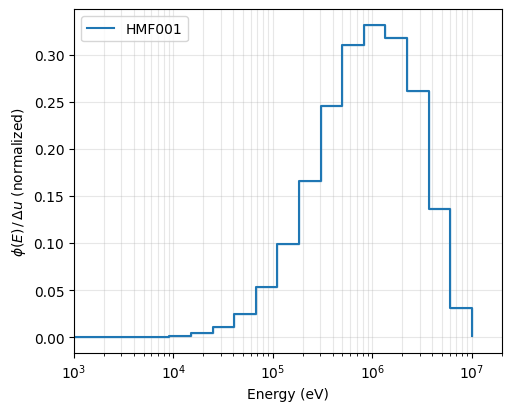

In [9]:
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")

hmf001.flux.plot_spectrum(ax=ax)

ax.set(xlim=(1e3, 2e7))

plt.show()

### 5. E-Index Similarity via AssimilationSuite
The E-index measures the cosine similarity between two sensitivity vectors:

$$
E_{ij} = \frac{S_i^T S_j}{\sqrt{S_i^T S_i \cdot S_j^T S_j}}
$$

Unlike $c_k$, the E-index does not involve a covariance matrix, so it captures purely geometric similarity of the sensitivity profiles. We construct a minimal `AssimilationSuite` with HMF001 as both the benchmark and the application to illustrate the API.

In [7]:
suite = andalus.AssimilationSuite.from_yaml("config.yaml")

Reading ../data/hmf001.ser_res.m
  - done
Reading ../data/hmf001.ser_sens0.m
  - done
Reading ../data/hmf002-001.ser_res.m
  - done
Reading ../data/hmf002-001.ser_sens0.m
  - done
Reading ../data/hmf002-002.ser_res.m
  - done
Reading ../data/hmf002-002.ser_sens0.m
  - done


In [8]:
e_index = suite.e_index_matrix()
print(e_index)

              HMF001  HMF002-001  HMF002-002
HMF001      1.000000    0.960530    0.957067
HMF002-001  0.960530    1.000000    0.999763
HMF002-002  0.957067    0.999763    1.000000


The diagonal entries equal 1.0 by construction. The off-diagonal value between the benchmark and application reflects how closely aligned their sensitivity profiles are in the multivariate nuclear-data space. An E-index near 1.0 indicates that the two systems are driven by the same energy and reaction dependencies, making the benchmark a strong predictor of the application's behavior.